<a href="https://colab.research.google.com/github/EvelynNguyenPortfolio/CS-349/blob/main/HWK3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import sys
assert sys.version_info >= (3, 10)
from packaging.version import Version
import sklearn
assert Version(sklearn.__version__) >= Version("1.6.1")
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

# Download data set
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


# Task 1: Load the dataset into a Pandas DataFrame

In [37]:
# Load the dataset into a Pandas DataFrame
def load_c_data():
    path = kagglehub.dataset_download(
        "blastchar/telco-customer-churn"
    )

    csv_file = list(Path(path).glob("*.csv"))[0]

    return pd.read_csv(csv_file)

c = load_c_data()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


## Task 2: Use structural inspection methods to analyze features

In [38]:
c.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
c.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [40]:
c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Task 3: Drop any non-informative identifiers

In [41]:
# Dropping noninformative identifier
c.drop(columns=["customerID"])

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Task 4: Quantify any missing or implicit missing values across the columns

In [42]:
# Finding missing values
c.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [43]:
# function to find whitespace matches
def count_spaces(col):
    return col.str.match(r'^\s*$')

# Passing function into apply()
whitespace_counts = c.astype(str).apply(count_spaces).sum()
print("Whitespace counts per column:\n", whitespace_counts)


Whitespace counts per column:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [44]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define clean function
def clean_spaces(col):
    if col.dtype == "object":
        return col.str.strip()
    return col

# Copy for clean data
c_clean = c.copy()

# Apply clean_spaces function and drop CustomerID
c_clean = c.apply(clean_spaces)
c_clean.drop(columns=["customerID"], inplace=True)

# Replace whitespace with 0
imputer = SimpleImputer(missing_values="", strategy="constant", fill_value='0')

# 3. Fit and transform your object columns
object_cols = c_clean.select_dtypes(include=['object']).columns
c_clean[object_cols] = imputer.fit_transform(c_clean[object_cols])

# Get number of columns with whitespace to confirm that fit and transform was successful
whitespace_counts = c_clean.astype(str).apply(count_spaces).sum()
print("Whitespace counts per column:\n", whitespace_counts)

Whitespace counts per column:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Change 'TotalCharges' to numeric because I want to interpret it as a continuous numeric value
c_clean['TotalCharges'] = pd.to_numeric(c_clean['TotalCharges'], errors='coerce')

# Change 'SeniorCitizen' to 'object' because I want to interpret it as a categorical value
c_clean["SeniorCitizen"] = c_clean["SeniorCitizen"].astype("object")

c_clean.info()

#Taking out target value
x_var = c_clean.drop('Churn', axis = 1)
y_var = c_clean['Churn']

#Separation of numerical and categorical data
num_var = x_var.select_dtypes(include=['float64', 'int64']).columns
cat_var = x_var.select_dtypes(include=['object']).columns

# Create pipeline for numeric values that will apply StandardScaler
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Create pipeline for categorical values that will apply OneHotEncoder
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(sparse_output = False)),
])

# Join the two pipelines and apply ColumnTransformer function
c_prep = fullpipeline = ColumnTransformer([
    ("num", num_pipeline, num_var),
    ("cat", cat_pipeline, cat_var),
])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [46]:
from sklearn.linear_model import SGDClassifier

# process the data and apply logistic regression
pipeline = Pipeline(steps=[
    ('preprocessor', c_prep),
    ('classifier', SGDClassifier(loss='log_loss', random_state=42))
])

# Task 7: Split your dataset into training and test sets using 3 different train/test split ratios

-------------------------------------------------------------------
 Performance for 80/20 Split 
-------------------------------------------------------------------

Confusion Matrix:
[[996  40]
 [242 131]]

Classification Report:
              precision    recall  f1-score   support

          No       0.80      0.96      0.88      1036
         Yes       0.77      0.35      0.48       373

    accuracy                           0.80      1409
   macro avg       0.79      0.66      0.68      1409
weighted avg       0.79      0.80      0.77      1409

ROC-AUC Score: 0.8492
-------------------------------------------------------------------
 Performance for 70/30 Split 
-------------------------------------------------------------------

Confusion Matrix:
[[1475   64]
 [ 398  176]]

Classification Report:
              precision    recall  f1-score   support

          No       0.79      0.96      0.86      1539
         Yes       0.73      0.31      0.43       574

    accuracy       

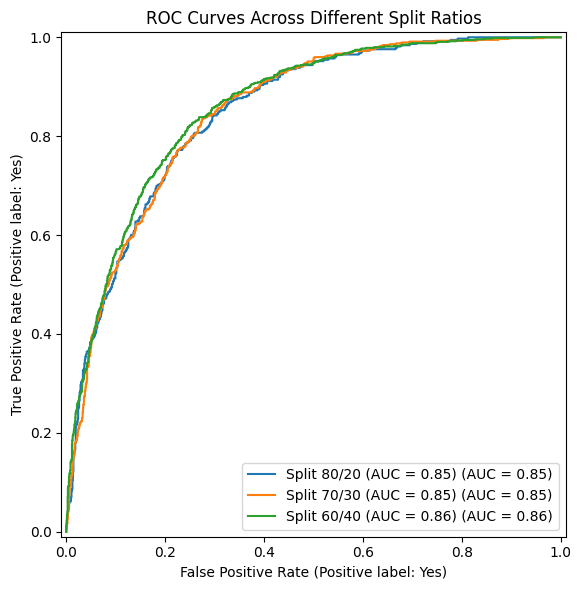

In [47]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score

test_sizes = [0.20, 0.30, 0.40]
ratios = ["80/20", "70/30", "60/40"]

fig, ax = plt.subplots(figsize=(8, 6))

for test_size, ratio in zip(test_sizes, ratios):
    # Split the dataset (using your X and y variables)
    X_train, X_test, y_train, y_test = train_test_split(x_var, y_var, test_size=test_size, random_state=42)

    # Fit the complete integrated pipeline
    pipeline.fit(X_train, y_train)

    # Predict classes and probabilities
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    print(f"-------------------------------------------------------------------")
    print(f" Performance for {ratio} Split ")
    print(f"-------------------------------------------------------------------")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    auc_score = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Plot ROC Curve onto the shared axis
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=f"Split {ratio} (AUC = {auc_score:.2f})")

ax.set_title("ROC Curves Across Different Split Ratios")
plt.tight_layout()
plt.show()

# Report on any performance differences detected across the various splitting ratios

According to the results, the 60/40 Split had the best all-around performer. While overall accuracy was roughly the same across all splits, the 60/40 split outperforms the others in predicting the Yes class.
Its recall for Yes is to 71% while the other splits are 35% and 31%. It also achieves the highest ROC-AUC (0.8594) and has the strongest overall ability
to distinguish between the two classes. For the 80/20 and 70/30 splits, the model has high precision but very low recall for the Yes class. When the model guessed Yes, it was usually right, 77% precision in 80/20. However, it missed the vast majority of actual Yes cases at 35% recall, choosing instead to safely guess No. In the 60/40 split, this behavior changes. The model becomes more aggressive at flagging Y cases, which lowers its precision to 61%, creating more false positive, but dramatically fixes the recall. The 60/40 confusion matrix serves as an example. The True Negatives is 1720. The False Positives is 349. The True Positives is 535. The False Negatives is 214.





# Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients

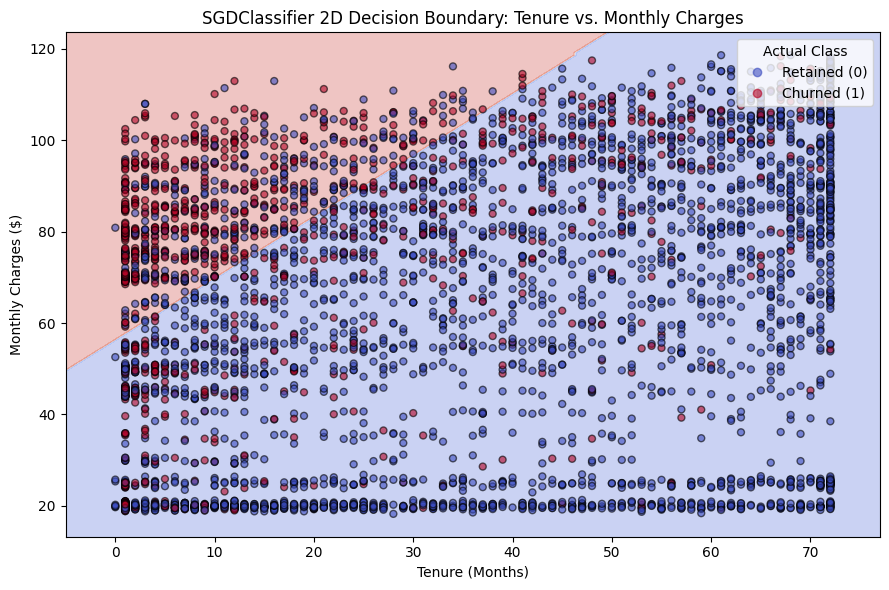

In [48]:
from sklearn.inspection import DecisionBoundaryDisplay

# Select two prominent numerical features for 2D visualization
feat_1 = 'tenure'
feat_2 = 'MonthlyCharges'

X_2d = X_train[[feat_1, feat_2]].copy()

# Build a pipeline for these two features
clf_2d = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

# Train the 2D model
clf_2d.fit(X_2d, y_train)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X_2d[feat_1].min() - 5, X_2d[feat_1].max() + 5
y_min, y_max = X_2d[feat_2].min() - 5, X_2d[feat_2].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the mesh grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid_points, columns=[feat_1, feat_2])
Z = clf_2d.predict(grid_df)

# Reshape Z
if Z.dtype.kind in ['U', 'S', 'O']:
    mapping = {'Yes': 1, 'No': 0, 'Churn': 1, 'Retain': 0, 'Churned': 1, 'Retained': 0}
    Z = np.array([mapping.get(val, val) for val in Z])

Z = Z.reshape(xx.shape).astype(float)

# Plotting the Customer Churn Data
plt.figure(figsize=(9, 6))

# 1. Draw the colored decision background zones
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# 2. Scatter plot of training samples mapped to Churn/Retain numbers
y_numeric = y_train.map({'No': 0, 'Yes': 1, 'Retain': 0, 'Churn': 1, 'Retained': 0, 'Churned': 1}) if hasattr(y_train, 'map') else y_train

scatter = plt.scatter(
    X_2d[feat_1],
    X_2d[feat_2],
    c=y_numeric,
    cmap=plt.cm.coolwarm,
    edgecolors='k',
    s=25,
    alpha=0.6
)

# 3. Add customer churn labels
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.title('SGDClassifier 2D Decision Boundary: Tenure vs. Monthly Charges')

# Create label mapping for Churn vs Retain
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Retained (0)', 'Churned (1)'], loc="upper right", title="Actual Class")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()


In [49]:
# Get the trained classifier from the final fitted pipeline loop
trained_classifier = pipeline.named_steps['classifier']

# Extract feature names correctly from 'c_prep' step
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 3. Create a clean DataFrame of coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': trained_classifier.coef_[0], # Extracted from the 2D array
    'Absolute_Coefficient': np.abs(trained_classifier.coef_[0])
}).sort_values(by='Absolute_Coefficient', ascending=False)

print(f"-------------------------------------------------------------------")
print(" Top Features Driving Churn Interpretation ")
print(f"-------------------------------------------------------------------")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

-------------------------------------------------------------------
 Top Features Driving Churn Interpretation 
-------------------------------------------------------------------
                                     Feature  Coefficient
                                 num__tenure    -1.286410
            cat__InternetService_Fiber optic     1.174105
                cat__Contract_Month-to-month     0.985982
                         num__MonthlyCharges    -0.815441
                           num__TotalCharges     0.689040
                        cat__StreamingTV_Yes     0.673293
                             cat__Partner_No     0.671595
                   cat__PaperlessBilling_Yes     0.614041
                       cat__PhoneService_Yes     0.606956
                    cat__StreamingMovies_Yes     0.597170
                          cat__Dependents_No     0.552995
                        cat__SeniorCitizen_1     0.544153
                   cat__DeviceProtection_Yes     0.542745
        

# Comparison of Standard Scaler and MinMax

In [50]:
from sklearn.preprocessing import MinMaxScaler

# Re-fit original StandardScaler pipeline to capture its metrics
pipeline.fit(X_train, y_train)


y_proba_std = pipeline.predict_proba(X_test)[:, 1]
y_pred_std = pipeline.predict(X_test)
auc_std = roc_auc_score(y_test, y_proba_std)
cm_std = confusion_matrix(y_test, y_pred_std)

# Build an identical pipeline with MinMaxScaler
minmax_num_pipeline = Pipeline([('scaler', MinMaxScaler())])
c_prep_minmax = ColumnTransformer([
    ("num", minmax_num_pipeline, num_var),
    ("cat", cat_pipeline, cat_var),
])
pipeline_minmax = Pipeline(steps=[
    ('preprocessor', c_prep_minmax),
    ('classifier', SGDClassifier(loss='log_loss', random_state=42))
])

# Fit the MinMaxScaler pipeline and capture its metrics and training time
pipeline_minmax.fit(X_train, y_train)

y_proba_mm = pipeline_minmax.predict_proba(X_test)[:, 1]
y_pred_mm = pipeline_minmax.predict(X_test)
auc_mm = roc_auc_score(y_test, y_proba_mm)
cm_mm = confusion_matrix(y_test, y_pred_mm)

# Print results
print(f"-------------------------------------------------------------------")
print(" EMPIRICAL PROOF: STANDARD vs MINMAX SCALER ")
print(f"-------------------------------------------------------------------")
print(f"StandardScaler ROC-AUC : {auc_std:.4f}")
print(f"MinMaxScaler  ROC-AUC : {auc_mm:.4f}")
print("\nStandardScaler Confusion Matrix:\n", cm_std)
print("MinMaxScaler Confusion Matrix:\n", cm_mm)



-------------------------------------------------------------------
 EMPIRICAL PROOF: STANDARD vs MINMAX SCALER 
-------------------------------------------------------------------
StandardScaler ROC-AUC : 0.8594
MinMaxScaler  ROC-AUC : 0.8495

StandardScaler Confusion Matrix:
 [[1720  349]
 [ 214  535]]
MinMaxScaler Confusion Matrix:
 [[1792  277]
 [ 293  456]]
